In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
df=pd.read_csv("india_insurance_claims_synthetic.csv")
df.head()


,claim_id,claim_date,claim_year,claim_month,insurer,state,vehicle_type,vehicle_age_years,policy_age_months,incident_type,garage_type,claim_amount_inr,claims_last_12m,days_to_report,surveyor_flag,india_cpi,india_gdp_growth,fraud_flag
0,CLM-000001,2015-01-01,2015,1,United India Insurance,Andhra Pradesh,Two-Wheeler,0,11,Collision,Network Garage,159965.85,0,4,1,4.91,8.0,0
1,CLM-000002,2015-01-01,2015,1,New India Assurance,Uttar Pradesh,Two-Wheeler,1,50,Collision,Non-Network Garage,73119.19,0,12,0,4.91,8.0,0
2,CLM-000003,2015-01-02,2015,1,Tata AIG,Karnataka,Two-Wheeler,13,3,Natural Disaster,Non-Network Garage,65555.55,1,3,0,4.91,8.0,0
3,CLM-000004,2015-01-02,2015,1,New India Assurance,Maharashtra,Private Car,5,4,Collision,Non-Network Garage,153417.83,1,5,1,4.91,8.0,0
4,CLM-000005,2015-01-02,2015,1,Bajaj Allianz,Gujarat,Two-Wheeler,0,40,Collision,Network Garage,67745.19,0,0,0,4.91,8.0,0


In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

features = [
    'claim_amount_inr',
    'vehicle_age_years',
    'policy_age_months',
    'claims_last_12m',
    'days_to_report',
    'india_cpi',
    'india_gdp_growth',
]

X = StandardScaler().fit_transform(df[features])

model = IsolationForest(contamination=0.10, random_state=42)
model.fit(X)

df['anomaly_score'] = model.decision_function(X).round(4)
df['anomaly_flag']  = (model.predict(X) == -1).astype(int)



In [7]:
print(df['anomaly_score'].describe())

count    15000.000000
mean         0.087774
std          0.058794
min         -0.145400
25%          0.050975
50%          0.100000
75%          0.134525
max          0.179000
Name: anomaly_score, dtype: float64


In [8]:
print(df['anomaly_score'].quantile([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]))

0.05   -0.025610
0.10    0.000000
0.25    0.050975
0.50    0.100000
0.75    0.134525
0.90    0.153700
0.95    0.161400
Name: anomaly_score, dtype: float64


(array([  3.,   3.,   8.,   6.,   7.,   7.,   8.,  19.,  20.,  20.,  35.,
         45.,  53.,  66.,  62.,  85., 109., 133., 142., 207., 175., 206.,
        196., 228., 240., 290., 320., 317., 311., 333., 345., 350., 385.,
        446., 519., 539., 670., 721., 741., 654., 688., 700., 728., 764.,
        756., 775., 645., 545., 287.,  88.]),
 array([-0.1454  , -0.138912, -0.132424, -0.125936, -0.119448, -0.11296 ,
        -0.106472, -0.099984, -0.093496, -0.087008, -0.08052 , -0.074032,
        -0.067544, -0.061056, -0.054568, -0.04808 , -0.041592, -0.035104,
        -0.028616, -0.022128, -0.01564 , -0.009152, -0.002664,  0.003824,
         0.010312,  0.0168  ,  0.023288,  0.029776,  0.036264,  0.042752,
         0.04924 ,  0.055728,  0.062216,  0.068704,  0.075192,  0.08168 ,
         0.088168,  0.094656,  0.101144,  0.107632,  0.11412 ,  0.120608,
         0.127096,  0.133584,  0.140072,  0.14656 ,  0.153048,  0.159536,
         0.166024,  0.172512,  0.179   ]),
 <BarContainer object o

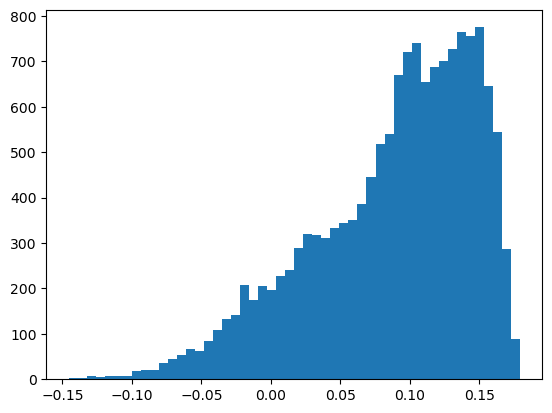

In [11]:
plt.hist(df['anomaly_score'], bins=50)

In [12]:
df.groupby('fraud_flag')['anomaly_score'].describe()

,count,mean,std,min,25%,50%,75%,max
fraud_flag,,,,,,,,
0,13444.0,0.093739,0.054659,-0.1454,0.061775,0.10455,0.136700,0.1790
1,1556.0,0.036236,0.067448,-0.1419,-0.013575,0.03930,0.087325,0.1779


<Axes: title={'center': 'anomaly_score'}, xlabel='fraud_flag'>

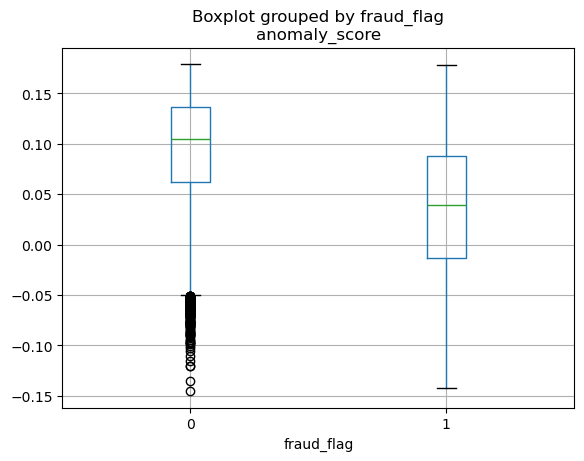

In [13]:
df.boxplot(column='anomaly_score',
           by='fraud_flag')

In [20]:
thresholds=[-0.025,0.0,0.05]
results = []
for i in thresholds:
    y_pred = (df['anomaly_score'] < i).astype(int)
    y_true = df['fraud_flag']
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    results.append({
        'Threshold': i,
        'Precision': round(precision,3),
        'Recall': round(recall,3),
        'F1 Score': round(f1,3),
        'Claims Flagged': int(y_pred.sum())
    })
results_df = pd.DataFrame(results)
results_df

,Threshold,Precision,Recall,F1 Score,Claims Flagged
0,-0.025,0.398,0.197,0.263,768
1,0.000,0.326,0.314,0.320,1498
2,0.050,0.236,0.562,0.333,3698


In [27]:
results_df.sort_values(
    'F1 Score',
    ascending=False
)

,Threshold,Precision,Recall,F1 Score,Claims Flagged
2,0.050,0.236,0.562,0.333,3698
1,0.000,0.326,0.314,0.320,1498
0,-0.025,0.398,0.197,0.263,768


In [29]:
#Threshold 0.05 achieved the highest F1 score, indicating the strongest balance between precision and recall on the synthetic dataset. However, this threshold classifies approximately 25% of all claims as anomalous, which may create an impractical investigation workload. For operational deployment, organizations may choose a lower threshold to focus resources on the most extreme anomalies

In [22]:
threshold = -0.025

y_pred = (df['anomaly_score'] < threshold).astype(int)

cm = confusion_matrix(
    df['fraud_flag'],
    y_pred
)
cm_df = pd.DataFrame(
    cm,
    index=['Actual Legit','Actual Fraud'],
    columns=['Predicted Legit','Predicted Fraud']
)

cm_df

,Predicted Legit,Predicted Fraud
Actual Legit,12982,462
Actual Fraud,1250,306


In [23]:
for threshold in thresholds:

    y_pred = (df['anomaly_score'] < threshold).astype(int)

    fraud_found = (
        (y_pred == 1) &
        (df['fraud_flag'] == 1)
    ).sum()

    total_fraud = df['fraud_flag'].sum()

    print(
        f"Threshold {threshold}: "
        f"Captured {fraud_found} of {total_fraud} fraud cases"
    )

Threshold -0.025: Captured 306 of 1556 fraud cases
Threshold 0.0: Captured 489 of 1556 fraud cases
Threshold 0.05: Captured 874 of 1556 fraud cases


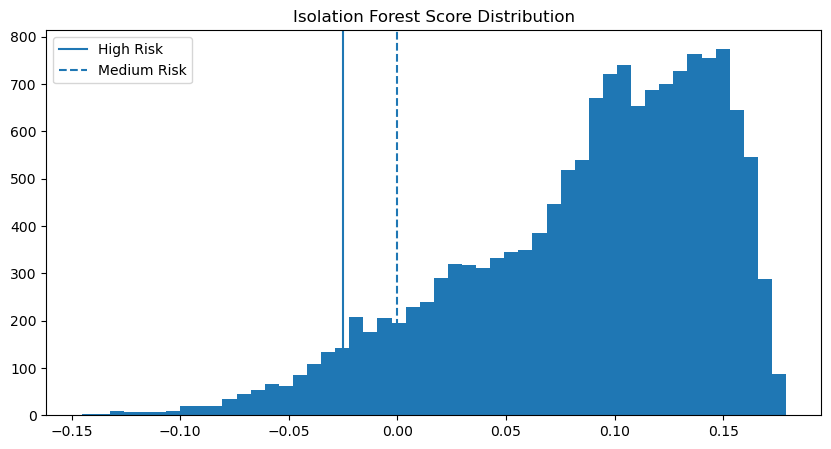

In [25]:
plt.figure(figsize=(10,5))

plt.hist(
    df['anomaly_score'],
    bins=50
)

plt.axvline(
    -0.025,
    linestyle='-',
    label='High Risk'
)

plt.axvline(
    0.0,
    linestyle='--',
    label='Medium Risk'
)

plt.legend()

plt.title("Isolation Forest Score Distribution")

plt.show()

In [26]:
def risk_label(score):
    if score < -0.025:   return 'High Risk'
    elif score < 0: return 'Medium Risk'
    else:               return 'Low Risk'

df['risk_level'] = df['anomaly_score'].apply(risk_label)
df.head()

,claim_id,claim_date,claim_year,claim_month,insurer,state,vehicle_type,vehicle_age_years,policy_age_months,incident_type,...,claim_amount_inr,claims_last_12m,days_to_report,surveyor_flag,india_cpi,india_gdp_growth,fraud_flag,anomaly_score,anomaly_flag,risk_level
0,CLM-000001,2015-01-01,2015,1,United India Insurance,Andhra Pradesh,Two-Wheeler,0,11,Collision,...,159965.85,0,4,1,4.91,8.0,0,0.1406,0,Low Risk
1,CLM-000002,2015-01-01,2015,1,New India Assurance,Uttar Pradesh,Two-Wheeler,1,50,Collision,...,73119.19,0,12,0,4.91,8.0,0,0.1327,0,Low Risk
2,CLM-000003,2015-01-02,2015,1,Tata AIG,Karnataka,Two-Wheeler,13,3,Natural Disaster,...,65555.55,1,3,0,4.91,8.0,0,0.0582,0,Low Risk
3,CLM-000004,2015-01-02,2015,1,New India Assurance,Maharashtra,Private Car,5,4,Collision,...,153417.83,1,5,1,4.91,8.0,0,0.1042,0,Low Risk
4,CLM-000005,2015-01-02,2015,1,Bajaj Allianz,Gujarat,Two-Wheeler,0,40,Collision,...,67745.19,0,0,0,4.91,8.0,0,0.1543,0,Low Risk


In [ ]:
#Although 0.05 produced the highest F1 score, the project intentionally reserves the High Risk category for the most statistically extreme anomalies, while Medium Risk captures additional suspicious claims.

In [30]:
df.to_csv(
    "claims_scored.csv",
    index=False
)